Load the MoleculeNet BACE1 dataset

In [ ]:
!pip install rdkit scikit-learn joblib

In [ ]:
import pandas as pd
df = pd.read_csv("hf://datasets/scikit-fingerprints/MoleculeNet_BACE/bace.csv")
df.shape

(1513, 2)

In [ ]:
from rdkit import Chem

create rdchem.Mol object from the smiles in a new column 'mol' and check if any molecule failed to convert

In [ ]:
df['mol']=df['SMILES'].apply(Chem.MolFromSmiles)
print(df.head())
print(df['mol'].isna().sum())

                                              SMILES  label  \
0  O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2c...      1   
1  Fc1cc(cc(F)c1)C[C@H](NC(=O)[C@@H](N1CC[C@](NC(...      1   
2  S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...      1   
3  S1(=O)(=O)C[C@@H](Cc2cc(O[C@H](COCC)C(F)(F)F)c...      1   
4  S1(=O)(=O)N(c2cc(cc3c2n(cc3CC)CC1)C(=O)N[C@H](...      1   

                                                mol  
0  <rdkit.Chem.rdchem.Mol object at 0x7b7e6b890350>  
1  <rdkit.Chem.rdchem.Mol object at 0x7b7e70729930>  
2  <rdkit.Chem.rdchem.Mol object at 0x7b7e69cb17e0>  
3  <rdkit.Chem.rdchem.Mol object at 0x7b7e69cb1850>  
4  <rdkit.Chem.rdchem.Mol object at 0x7b7e69cb18c0>  
0


now we check the distribution of the activity

In [ ]:
print(df['label'].value_counts())
print(df['label'].value_counts(normalize=True))

label
0    822
1    691
Name: count, dtype: int64
label
0    0.543291
1    0.456709
Name: proportion, dtype: float64


We now calculate the Molecular Descriptors for the given SMILES and then get a summary of each descriptor to better understand what each is

In [ ]:
from rdkit.ML.Descriptors import MoleculeDescriptors
descriptor_names = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "MolMR",
    "NumHDonors",
    "NumHAcceptors",
    "NumRotatableBonds",
    "HeavyAtomCount",
    "FractionCSP3",
    "RingCount",
    "NumAromaticRings",
    "NumAliphaticRings",
    "NumSaturatedRings",
    "NumHeterocycles",
    "NumAromaticHeterocycles",
    "NumAliphaticHeterocycles",
    "NumValenceElectrons",
    "NumRadicalElectrons",
    "LabuteASA",
    "BertzCT"
]
calculator=MoleculeDescriptors.MolecularDescriptorCalculator(descriptor_names)
calculator.GetDescriptorSummaries()

['The average molecular weight of the molecule',
 'Wildman-Crippen LogP value',
 'N/A',
 'Wildman-Crippen MR value',
 'Number of Hydrogen Bond Donors',
 'Number of Hydrogen Bond Acceptors',
 'Number of Rotatable Bonds',
 'Number of heavy atoms a molecule.',
 'CalcFractionCSP3( (Mol)mol) -> float : returns the fraction of C atoms that are SP3 hybridized',
 'N/A',
 'CalcNumAromaticRings( (Mol)mol) -> int : returns the number of aromatic rings for a molecule',
 'CalcNumAliphaticRings( (Mol)mol) -> int : returns the number of aliphatic (containing at least one non-aromatic bond) rings for a molecule',
 'CalcNumSaturatedRings( (Mol)mol) -> int : returns the number of saturated rings for a molecule',
 'CalcNumHeterocycles( (Mol)mol) -> int : returns the number of heterocycles for a molecule',
 'CalcNumAromaticHeterocycles( (Mol)mol) -> int : returns the number of aromatic heterocycles for a molecule',
 'CalcNumAliphaticHeterocycles( (Mol)mol) -> int : returns the number of aliphatic (contain

now we run the descriptor calculation for each of the SMILES and check the new dataframe

In [ ]:
descriptor_values=df['mol'].apply(calculator.CalcDescriptors)

descriptor_df=pd.DataFrame(descriptor_values.tolist(),columns=descriptor_names, index=df.index)
descriptor_df.head()
descriptor_df.shape

(1513, 20)

we identify if any value is missing and look at how each descriptor has their own numerical range. for logistic regression we would have to normalize the scale

In [ ]:
print(descriptor_df.isna().sum().sum())
descriptor_df.describe().T

0


,count,mean,std,min,25%,50%,75%,max
MolWt,1513.0,479.671640,122.085059,138.190000,389.337000,463.639000,564.650000,1350.495000
MolLogP,1513.0,3.124880,1.247588,-6.457000,2.416500,3.137700,3.876900,7.293300
TPSA,1513.0,95.187958,33.187410,16.610000,72.940000,90.690000,110.180000,525.060000
MolMR,1513.0,129.209290,31.433061,39.565900,104.715800,125.280100,151.170600,342.344800
NumHDonors,1513.0,2.435558,1.242429,1.000000,1.000000,3.000000,3.000000,15.000000
NumHAcceptors,1513.0,4.699934,1.565537,0.000000,4.000000,5.000000,6.000000,18.000000
NumRotatableBonds,1513.0,7.679445,4.687279,0.000000,4.000000,7.000000,11.000000,40.000000
HeavyAtomCount,1513.0,34.089227,8.520088,10.000000,28.000000,33.000000,40.000000,97.000000
FractionCSP3,1513.0,0.369848,0.155931,0.000000,0.250000,0.363636,0.500000,0.894737
RingCount,1513.0,3.777264,0.892331,0.000000,3.000000,4.000000,4.000000,7.000000


now we check which values are highly correlated. they are removed as correlated values are redundant and can be safely dropped

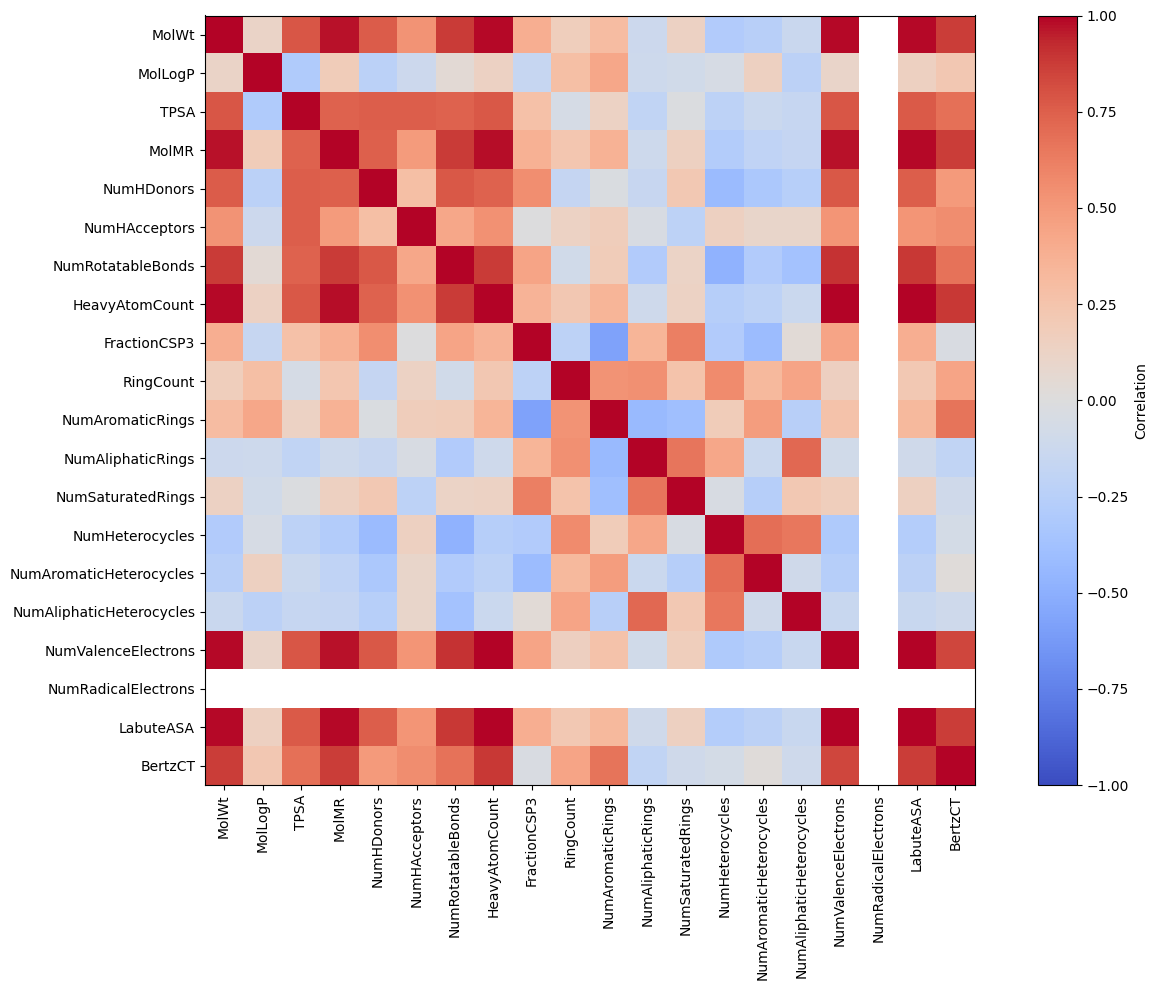

In [ ]:
corr = descriptor_df.corr()
corr.round(2)
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 10))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)
plt.tight_layout()
plt.show()

Now we remove values with zero variance as their values are similar for all molecules and thus do not have meaningful information

In [ ]:
zero_variance = descriptor_df.columns[
    descriptor_df.var() == 0
]

zero_variance

Index(['NumRadicalElectrons'], dtype='object')

Now we replace descriptor_df with a new df which removes correlated values and values with zero variance

In [ ]:
descriptor_names = [
    "MolWt",
    "MolLogP",
    "TPSA",
    "NumHDonors",
    "NumHAcceptors",
    "NumRotatableBonds",
    "FractionCSP3",
    "RingCount",
    "NumAromaticRings",
    "NumAliphaticRings",
    "NumSaturatedRings",
    "NumHeterocycles",
    "NumAromaticHeterocycles",
    "NumAliphaticHeterocycles",
    "BertzCT"
]
descriptor_df = descriptor_df[descriptor_names]
descriptor_df.shape

(1513, 15)

now we rename the dataframes for convenience

In [ ]:
x=descriptor_df
y=df['label']
print(x.shape)
print(y.shape)

(1513, 15)
(1513,)


We split the dataset into training and testing datasets and check if they have the same ratio of 0/1 label

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
print("Training:")
print(y_train.value_counts(normalize=True))
print("\nTest:")
print(y_test.value_counts(normalize=True))

Training:
label
0    0.542975
1    0.457025
Name: proportion, dtype: float64

Test:
label
0    0.544554
1    0.455446
Name: proportion, dtype: float64


we now run a pipeline to first have a standard scale for all descriptors and then use that to train the logistic regression model

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

lr_descriptor = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(random_state=42, max_iter=1000))
])
lr_descriptor.fit(X_train, y_train)

now we use the testing data to evaluate the model

In [ ]:
y_pred = lr_descriptor.predict(X_test)
y_prob = lr_descriptor.predict_proba(X_test)[:, 1]

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall   :", recall_score(y_test, y_pred))
print("F1 Score :", f1_score(y_test, y_pred))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob))

Accuracy : 0.6336633663366337
Precision: 0.6363636363636364
Recall   : 0.45652173913043476
F1 Score : 0.5316455696202531
ROC-AUC  : 0.7299077733860342


now we use the same descriptors to train a RandomForest Classifier. Note that random forest doesn't need to have a standard scale

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_descriptor = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_descriptor.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

we now evaluate our random forest model with the testing data

In [ ]:
y_pred_rf = rf_descriptor.predict(X_test)
y_prob_rf = rf_descriptor.predict_proba(X_test)[:, 1]
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC-AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.7788778877887789
Precision: 0.7933884297520661
Recall   : 0.6956521739130435
F1 Score : 0.7413127413127413
ROC-AUC  : 0.846157224418094


Now we calculate the Morgan Fingerprints of our molecules and create a new dataframe of the fingerprints

In [ ]:
from rdkit.Chem import rdFingerprintGenerator

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(
    radius=2,
    fpSize=2048
)
fingerprints = [
    morgan_generator.GetFingerprintAsNumPy(mol)
    for mol in df["mol"]
]
fp_df = pd.DataFrame(fingerprints, index=df.index)
fp_df.shape

(1513, 2048)

we rename our datasets for easier usage and then use the exact same 80/20 split we originally made by using location indexes

In [ ]:
X_fp = fp_df
X_fp_train = X_fp.loc[X_train.index]
X_fp_test = X_fp.loc[X_test.index]
y_fp_train = y_train
y_fp_test = y_test
print(X_fp_train.shape)
print(X_fp_test.shape)

(1210, 2048)
(303, 2048)


We now train a Logistic Regression model on the training set with fingerprints. Note that for fingerprints the model does not need the standard scaler as all fingerprint values are binary 0 or 1 so they have the same scale

In [ ]:
lr_fp = LogisticRegression(
    random_state=42,
    max_iter=1000
)
lr_fp.fit(X_fp_train, y_fp_train)

LogisticRegression(max_iter=1000, random_state=42)

We evaluate the new Logistic Regression model using the test set

In [ ]:
y_pred_lr_fp = lr_fp.predict(X_fp_test)
y_prob_lr_fp = lr_fp.predict_proba(X_fp_test)[:, 1]
print("Accuracy :", accuracy_score(y_fp_test, y_pred_lr_fp))
print("Precision:", precision_score(y_fp_test, y_pred_lr_fp))
print("Recall   :", recall_score(y_fp_test, y_pred_lr_fp))
print("F1 Score :", f1_score(y_fp_test, y_pred_lr_fp))
print("ROC-AUC  :", roc_auc_score(y_fp_test, y_prob_lr_fp))

Accuracy : 0.7788778877887789
Precision: 0.762962962962963
Recall   : 0.7463768115942029
F1 Score : 0.7545787545787546
ROC-AUC  : 0.8882520860781731


We now train a random forest classifier using the fingerprints with the same training set

In [ ]:
rf_fp = RandomForestClassifier(
    n_estimators=300,
    random_state=42,
    n_jobs=-1
)
rf_fp.fit(X_fp_train, y_fp_train)

RandomForestClassifier(n_estimators=300, n_jobs=-1, random_state=42)

We evaluate the new random forest model using the test set

In [ ]:
y_pred_rf_fp = rf_fp.predict(X_fp_test)
y_prob_rf_fp = rf_fp.predict_proba(X_fp_test)[:, 1]
print("Accuracy :", accuracy_score(y_fp_test, y_pred_rf_fp))
print("Precision:", precision_score(y_fp_test, y_pred_rf_fp))
print("Recall   :", recall_score(y_fp_test, y_pred_rf_fp))
print("F1 Score :", f1_score(y_fp_test, y_pred_rf_fp))
print("ROC-AUC  :", roc_auc_score(y_fp_test, y_prob_rf_fp))

Accuracy : 0.7788778877887789
Precision: 0.75177304964539
Recall   : 0.7681159420289855
F1 Score : 0.7598566308243727
ROC-AUC  : 0.881993851559069


To get a better evaluation metric, we use a KFold splitting stratergy and split our training data into 5 parts and run a 5 fold testing to get a better evaluation.

In [ ]:
from sklearn.model_selection import StratifiedKFold
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)
from sklearn.model_selection import cross_validate
scoring = {
    "roc_auc": "roc_auc",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

We run the cross-validator for all 4 of our models

In [ ]:
cv_lr_desc = cross_validate(
    lr_descriptor,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
cv_rf_desc = cross_validate(
    rf_descriptor,
    X_train,
    y_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
cv_lr_fp = cross_validate(
    lr_fp,
    X_fp_train,
    y_fp_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)
cv_rf_fp = cross_validate(
    rf_fp,
    X_fp_train,
    y_fp_train,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

we tabulate the evaluation data of all four of our models which were evaluated by the cross validation

In [ ]:
models = {
    "LR + Descriptors": cv_lr_desc,
    "RF + Descriptors": cv_rf_desc,
    "LR + Morgan FP": cv_lr_fp,
    "RF + Morgan FP": cv_rf_fp
}

cv_results = []

for name, result in models.items():
    row = {"Model": name}

    for metric in scoring:
        values = result[f"test_{metric}"]
        row[metric.upper()] = f"{values.mean():.3f} ± {values.std():.3f}"

    cv_results.append(row)

cv_results_df = pd.DataFrame(cv_results)

cv_results_df

,Model,ROC_AUC,ACCURACY,PRECISION,RECALL,F1
0,LR + Descriptors,0.742 ± 0.040,0.667 ± 0.042,0.655 ± 0.056,0.581 ± 0.031,0.615 ± 0.040
1,RF + Descriptors,0.858 ± 0.014,0.789 ± 0.007,0.775 ± 0.020,0.761 ± 0.028,0.767 ± 0.009
2,LR + Morgan FP,0.891 ± 0.011,0.809 ± 0.031,0.797 ± 0.040,0.783 ± 0.033,0.790 ± 0.033
3,RF + Morgan FP,0.888 ± 0.021,0.819 ± 0.024,0.804 ± 0.030,0.799 ± 0.027,0.801 ± 0.026


finally we download the useful models to be used for our streamlit app

In [ ]:
import joblib
joblib.dump(lr_fp, "lr_morgan.joblib")
joblib.dump(rf_fp, "rf_morgan.joblib")

from google.colab import files
files.download("lr_morgan.joblib")
files.download("rf_morgan.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Now we write the code for generating the app.py of our streamlit app

In [ ]:
%%writefile app.py
import streamlit as st
import joblib
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator

st.set_page_config(page_title="BACE Activity Predictor",page_icon="🧬",layout="centered")
lr = joblib.load("lr_morgan.joblib")
rf = joblib.load("rf_morgan.joblib")

morgan_generator = rdFingerprintGenerator.GetMorganGenerator(radius=2,fpSize=2048)

def predict_activity(smiles):
    mol = Chem.MolFromSmiles(smiles)

    if mol is None:
        return None, None, None, None, None, None

    fp = morgan_generator.GetFingerprintAsNumPy(mol).reshape(1, -1)

    lr_pred = lr.predict(fp)[0]
    lr_prob = lr.predict_proba(fp)[0, 1]
    lr_iprob = lr.predict_proba(fp)[0, 0]

    rf_pred = rf.predict(fp)[0]
    rf_prob = rf.predict_proba(fp)[0, 1]
    rf_iprob = rf.predict_proba(fp)[0, 0]

    return (lr_pred, lr_prob, lr_iprob,rf_pred, rf_prob, rf_iprob)


st.title("BACE Activity Predictor")

st.markdown(
    "Predict BACE activity from a molecular **SMILES** representation "
    "using two machine-learning models trained on Morgan fingerprints."
)
st.markdown(
    "Refer to the Github Page for detailed report on the project: [Github Repo](https://github.com/giridhari19/BACE1-activity-predictor)"
)
st.caption(
    "Predictions are model outputs and do not constitute experimental "
    "confirmation of biological activity."
)

st.subheader("Molecule")
smiles = st.text_area(
    "SMILES",
    placeholder="Enter a molecular SMILES string...",
    height=100,
    label_visibility="collapsed"
)

st.text("Try an example molecule. Click the copy button")
row1 = st.columns(2)
with row1[0]:
    st.markdown("**Example 1 (Active)**")
    st.code(
        "O1CC[C@@H](NC(=O)[C@@H](Cc2cc3cc(ccc3nc2N)-c2ccccc2C)C)CC1(C)C",
        language=None
    )
with row1[1]:
    st.markdown("**Example 2 (Inactive)**")
    st.code(
        "O(C)c1ccc(cc1C)[C@@]1(N=C(N)N(C)C1=O)C12CC3CC(C1)CC(C2)C3",
        language=None
    )
row2 = st.columns(2)
with row2[0]:
    st.markdown("**Example 3 (Inactive)**")
    st.code(
        "n1ccc2c(cccc2)c1N",
        language=None
    )
with row2[1]:
    st.markdown("**Example 4 (Active)**")
    st.code(
        "Oc1ccc(cc1CC)CC[NH3+]",
        language=None
    )


predict_button = st.button(
    "Predict Activity",
    type="primary",
    use_container_width=True
)

if predict_button:

    if not smiles.strip():
        st.warning("Please enter a SMILES string.")
    else:
        results = predict_activity(smiles.strip())

        if results[0] is None:
            st.error("Invalid SMILES. Please check the molecular structure and try again.")
        else:
            (lr_pred, lr_prob, lr_iprob,rf_pred, rf_prob, rf_iprob) = results
            st.divider()
            st.subheader("Prediction Results")
            col1, col2 = st.columns(2)
            # Logistic Regression
            with col1:
                st.markdown("### Logistic Regression")
                if lr_pred == 1:
                    st.success("ACTIVE")
                else:
                    st.info("INACTIVE")
                st.metric(
                    "Active probability",
                    f"{lr_prob:.2%}"
                )
                st.metric(
                    "Inactive probability",
                    f"{lr_iprob:.2%}"
                )

            # Random Forest
            with col2:
                st.markdown("### Random Forest")

                if rf_pred == 1:
                    st.success("ACTIVE")
                else:
                    st.info("INACTIVE")

                st.metric(
                    "Active probability",
                    f"{rf_prob:.2%}"
                )

                st.metric(
                    f"Inactive probability",
                    f"{rf_iprob:.2%}"
                )

st.divider()
st.subheader("Methodology")
col1, col2, col3 = st.columns(3)

with col1:
    st.markdown("**Dataset**")
    st.write("[MoleculeNet BACE](https://huggingface.co/datasets/scikit-fingerprints/MoleculeNet_BACE)")

with col2:
    st.markdown("**Representation**")
    st.write("Morgan fingerprint")

with col3:
    st.markdown("**Models**")
    st.write("Logistic Regression\nRandom Forest")

Next we write code to generate the requirements.txt for our app

In [ ]:
%%writefile requirements.txt
streamlit
scikit-learn==1.6.1
joblib
numpy
rdkit

Deployed app: [Streamlit Community Cloud link](https://bace1-activity-predictor.streamlit.app/)